# Use isolate as a python module
This example shows the use of the ``isolate`` function by importing it directly to your python environment. 
`isolate` generates a mask for the cerebellum and brain stem for a T1w and/or T2w anatomical image. The mask is then used in the subsequent normalization step, but should also be used to prevent contamination of data from the abutting neocortex into the superior cerebellum (see below)

In [1]:
# Import necessary packages
from nilearn import plotting
import SUITPy as suit
import nibabel as nib
import ants

## Basic usage 
In the simplest case, `isolate` function takes just the T1-weight image as a parameter: 

In [2]:
# This function generates isolation mask for the cerebellum based on a T1 scan and return it as ANTsImage
mask = suit.isolate('sub-ex_T1w.nii.gz')

preprocessing sub-ex_T1w.nii.gz
isolating cerebellum using UNet model
postprocessing
saving results to sub-ex_T1w_cerebellum_dseg.nii.gz


The binary mask image for the cerebellum is saved in the same directory as the source image as `<basename>_cerebellum_dseg.nii.gz`.


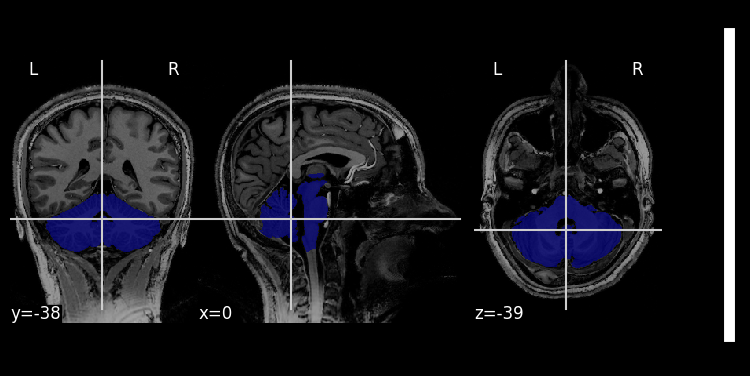

In [3]:
# Visualize the results:
img = nib.load('sub-ex_T1w.nii.gz')
mask = nib.load('sub-ex_T1w_cerebellum_dseg.nii.gz')
plotting.plot_roi(mask,img)

## Using T2 (and T1) image 
The isolation Unet is also trained on T2-weighted images 

In [4]:
suit.isolate(t2_file='sub-ex_T2w.nii.gz')

preprocessing sub-ex_T2w.nii.gz
isolating cerebellum using UNet model
postprocessing
saving results to sub-ex_T2w_cerebellum_dseg.nii.gz


ANTsImage (RPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (128, 128, 128)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-64.0, 114.0, -88.0)
	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.]

/var/folders/vh/tsrrmndj3kj8fm3m4p51k3nc0000gn/T/ipykernel_14257/1157470123.py:3: UserWarning: Casting data from int16 to float32
  plotting.plot_roi(mask,img)


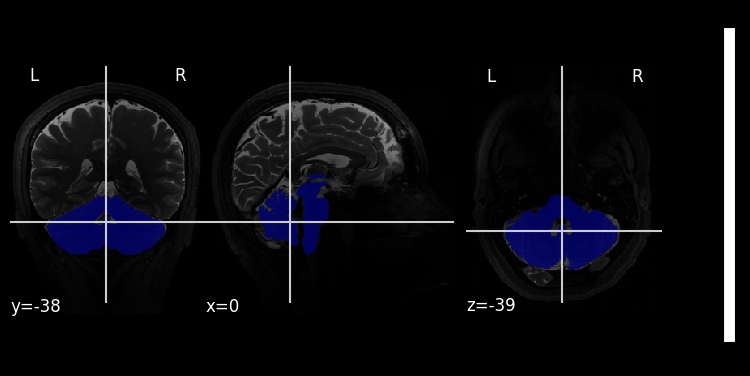

In [5]:
img = nib.load('sub-ex_T2w.nii.gz')
mask = nib.load('sub-ex_T2w_cerebellum_dseg.nii.gz')
plotting.plot_roi(mask,img)

## Brain mask
`isolate` function has an optional parameter `brain_mask_file` to accept the subject's brain mask (aligned with the input image). It could help the registration and isolation, especially with input images that have significantly more or less structure than the template. **Important: If the input images are already being skull stripped, the `brain_mask_file` is necessary. Otherwise, the registration would align a brain with the template head which leads to inaccurate results.**


## Registration (Additional function)
To obtain a robust initial affine transformation to get the bounding box correctly, the function `isolate` calls the function `isolation.registration` internally. 
It can run ants registration multiple times to produce better alignment. Check the function reference for detailed usage. If the resultant mask is not good, or seems cut-off on one side, it is likely that the initial registration step did not work well. You can try to run the restration function separately and check the output. If the registration is not good, you can try to adjust the parameters of the registration function. 

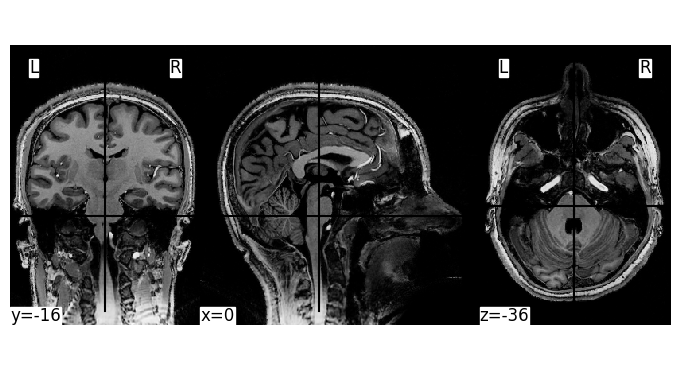

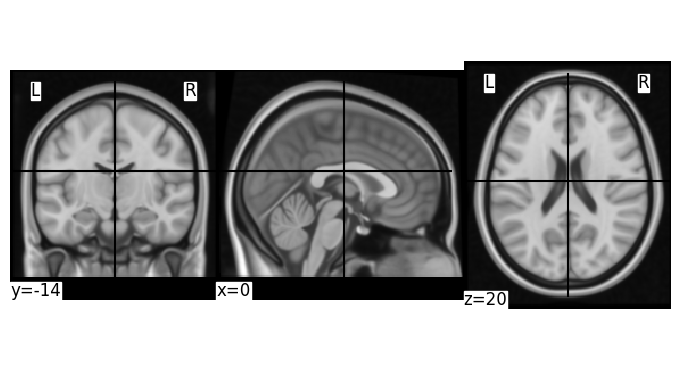

In [6]:
# This is visual comparison of img and template
img = nib.load('sub-ex_T1w.nii.gz')
template =ants.image_read('../../../SUITPy/templates/tpl-MNI152NLin6Asym_T1w.nii.gz')
plotting.plot_img(img, colorbar=False)
plotting.plot_img(ants.to_nibabel_nifti(template), colorbar=False)

In [7]:
# The function return the ANTsTransform
img = ants.image_read('sub-ex_T1w.nii.gz')
trans, status = suit.registration(img=img, max_iterations=5, mi_lower=1.22, mi_upper=1.23)
transformed_img = ants.apply_ants_transform_to_image(trans, img, template)


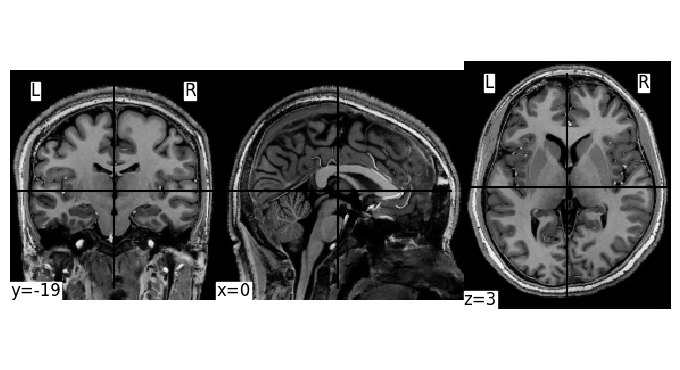

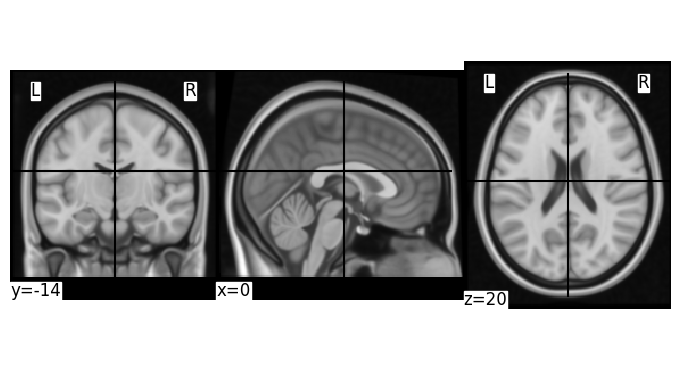

In [8]:
# img after registration
plotting.plot_img(ants.to_nibabel_nifti(transformed_img), colorbar=False)
plotting.plot_img(ants.to_nibabel_nifti(template), colorbar=False)